In [2]:
from typing import TypedDict, List
from langgraph.graph import START, END, StateGraph

In [3]:
class AmarAgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [4]:
def process_values(state: AmarAgentState) -> AmarAgentState:
    """This function handles multiple different inputs"""
    
    state["result"] = f"Hi there {state['name']}! Your sum is {sum(state['values'])}"

    return state

In [5]:
graph = StateGraph(AmarAgentState)

graph.add_node("processor", process_values) 
graph.set_entry_point("processor") # set the starting node
graph.set_finish_point("processor") # set the ending node

app = graph.compile() # compile the graph

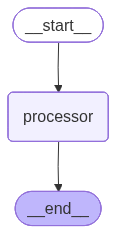

In [6]:
# visualize

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
answer = app.invoke({"values": [10, 20, 30], "name": "Abir"})

In [8]:
answer["result"]

'Hi there Abir! Your sum is 60'